In [3]:
# =============================================================================
# Notebook 07
# Spatial Variability Analysis
# =============================================================================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

OUTPUT = Path("datasets/radar_statistics")
FIGURES = Path("figures/notebook07")

FIGURES.mkdir(
    parents=True,
    exist_ok=True
)

mean_grid = np.load(OUTPUT / "mean_grid.npy")
std_grid = np.load(OUTPUT / "std_grid.npy")
max_grid = np.load(OUTPUT / "max_grid.npy")
rain_probability = np.load(
    OUTPUT / "rain_probability.npy"
)

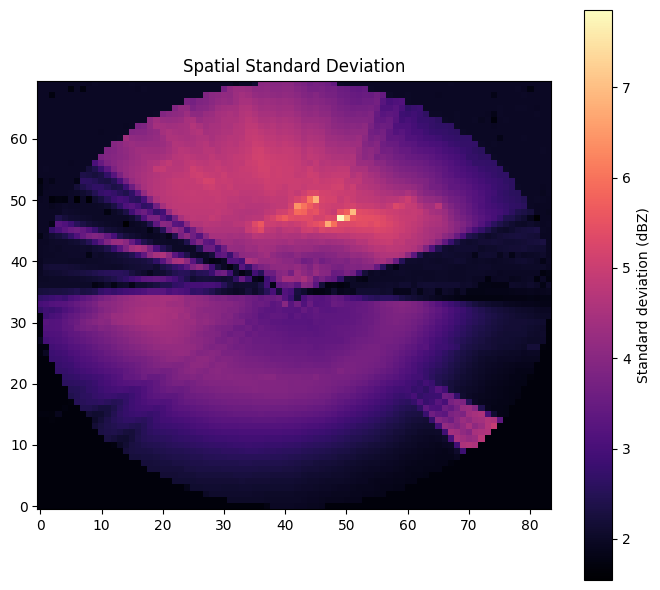

In [4]:
# =============================================================================
# Figure 1
# Standard deviation
# =============================================================================

plt.figure(figsize=(7,6))

im = plt.imshow(
    std_grid,
    origin="lower",
    cmap="magma"
)

plt.colorbar(
    im,
    label="Standard deviation (dBZ)"
)

plt.title("Spatial Standard Deviation")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure01_std_map.png",
    dpi=300
)

plt.show()

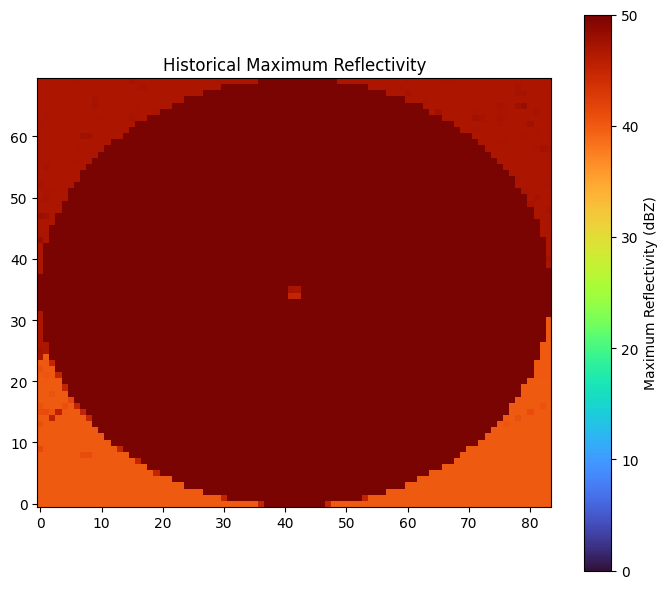

In [5]:
# =============================================================================
# Figure 2
# Maximum reflectivity
# =============================================================================

plt.figure(figsize=(7,6))

im = plt.imshow(
    max_grid,
    origin="lower",
    cmap="turbo",
    vmin=0,
    vmax=50
)

plt.colorbar(
    im,
    label="Maximum Reflectivity (dBZ)"
)

plt.title("Historical Maximum Reflectivity")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure02_maximum_map.png",
    dpi=300
)

plt.show()

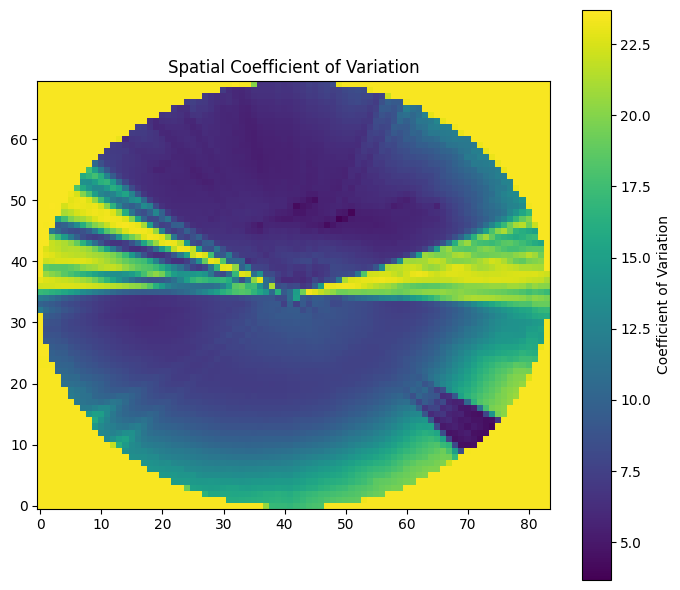

In [6]:
# =============================================================================
# Figure 3
# Coefficient of Variation
# =============================================================================

cv = std_grid / (mean_grid + 1e-6)

plt.figure(figsize=(7,6))

im = plt.imshow(
    cv,
    origin="lower",
    cmap="viridis"
)

plt.colorbar(
    im,
    label="Coefficient of Variation"
)

plt.title("Spatial Coefficient of Variation")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure03_cv_map.png",
    dpi=300
)

plt.show()

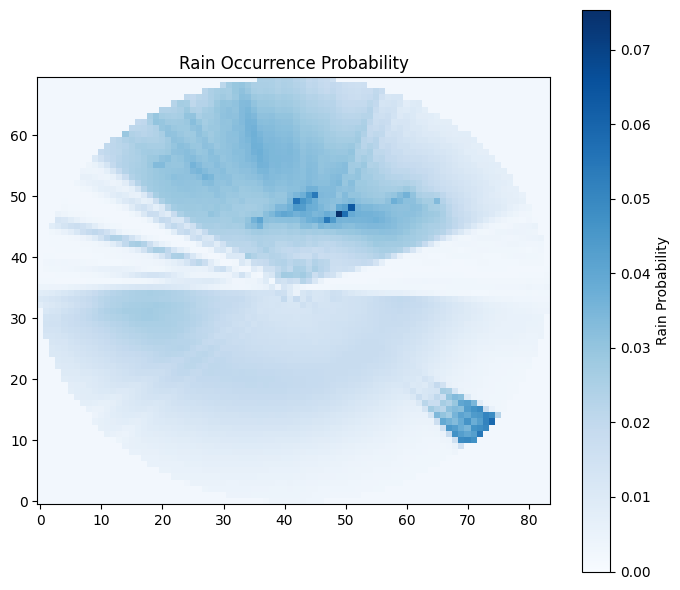

In [7]:
# =============================================================================
# Figure 4
# Rain Probability
# =============================================================================

plt.figure(figsize=(7,6))

im = plt.imshow(
    rain_probability,
    origin="lower",
    cmap="Blues",
    vmin=0,
    vmax=np.nanmax(rain_probability)
)

plt.colorbar(
    im,
    label="Rain Probability"
)

plt.title("Rain Occurrence Probability")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure04_probability.png",
    dpi=300
)

plt.show()

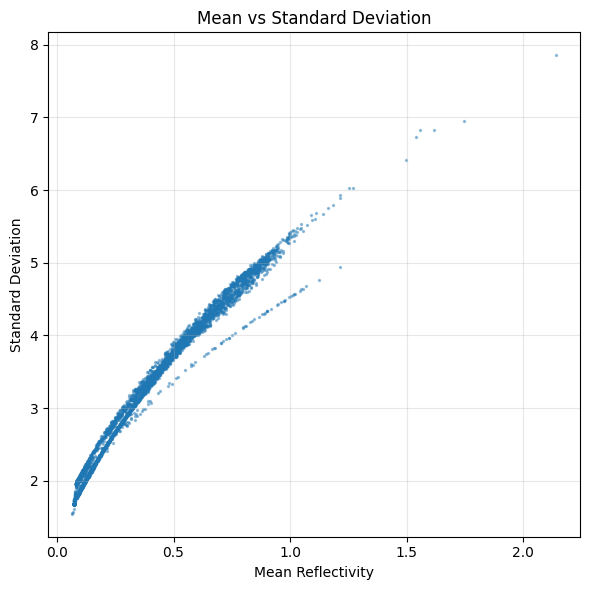

In [8]:
# =============================================================================
# Figure 5
# Mean x Std
# =============================================================================

mask = np.isfinite(mean_grid) & np.isfinite(std_grid)

plt.figure(figsize=(6,6))

plt.scatter(
    mean_grid[mask],
    std_grid[mask],
    s=2,
    alpha=0.4
)

plt.xlabel("Mean Reflectivity")

plt.ylabel("Standard Deviation")

plt.title("Mean vs Standard Deviation")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES/"figure05_mean_vs_std.png",
    dpi=300
)

plt.show()

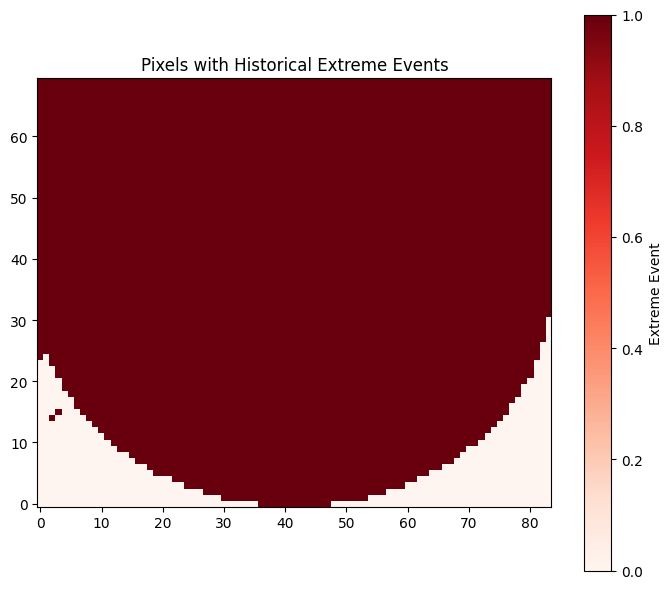

In [9]:
# =============================================================================
# Figure 6
# Extreme pixels
# =============================================================================

extreme = (max_grid >= 45).astype(float)

plt.figure(figsize=(7,6))

im = plt.imshow(
    extreme,
    origin="lower",
    cmap="Reds"
)

plt.colorbar(
    im,
    label="Extreme Event"
)

plt.title("Pixels with Historical Extreme Events")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure06_extremes.png",
    dpi=300
)

plt.show()

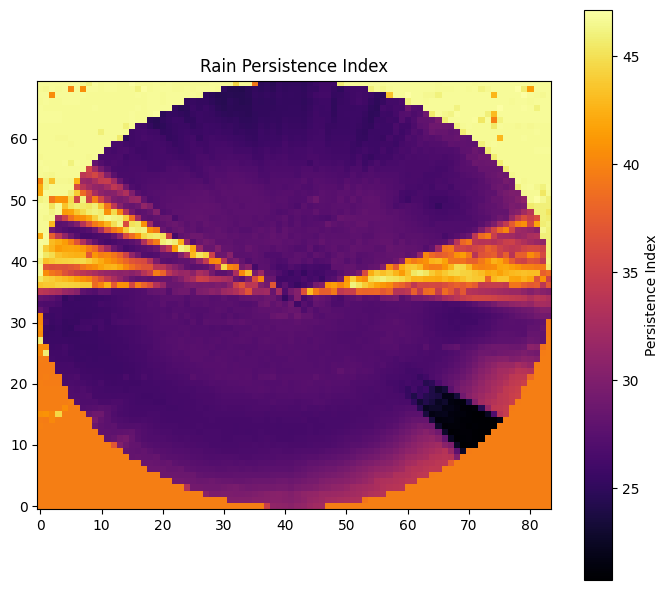

In [10]:
# =============================================================================
# Figure 7
# Rain persistence
# =============================================================================

persistence = mean_grid / (rain_probability + 1e-6)

plt.figure(figsize=(7,6))

im = plt.imshow(
    persistence,
    origin="lower",
    cmap="inferno"
)

plt.colorbar(
    im,
    label="Persistence Index"
)

plt.title("Rain Persistence Index")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure07_persistence.png",
    dpi=300
)

plt.show()

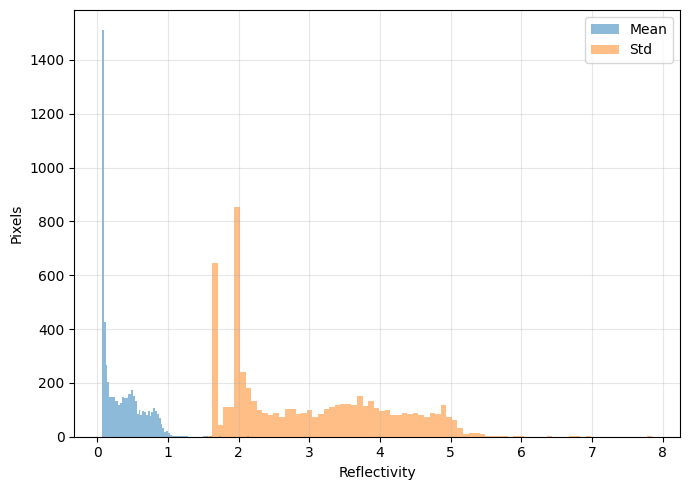

In [11]:
# =============================================================================
# Figure 8
# Histogram
# =============================================================================

plt.figure(figsize=(7,5))

plt.hist(
    mean_grid.flatten(),
    bins=80,
    alpha=0.5,
    label="Mean"
)

plt.hist(
    std_grid.flatten(),
    bins=80,
    alpha=0.5,
    label="Std"
)

plt.legend()

plt.xlabel("Reflectivity")

plt.ylabel("Pixels")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES/"figure08_histograms.png",
    dpi=300
)

plt.show()